# Network Intrusion Detection — XAI 




In [ ]:
# Imports + dataset loading 
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    r2_score, mean_absolute_error, mean_squared_error, f1_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping
import kagglehub

path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
print("Dataset directory:", path)

csv_candidates = glob.glob(
    os.path.join(path, "**", "Friday-WorkingHours-Morning.pcap_ISCX.csv"),
    recursive=True
)
if not csv_candidates:
    raise FileNotFoundError(
        "Could not find Friday-WorkingHours-Morning.pcap_ISCX.csv."
    )
csv_path = csv_candidates[0]
print("CSV file:", csv_path)


file_size = os.path.getsize(csv_path)
chunks = []
with tqdm(total=file_size, unit="B", unit_scale=True, desc="Loading CSV") as pbar:
    for chunk in pd.read_csv(csv_path, chunksize=20_000, low_memory=False):
        chunks.append(chunk)
        pbar.update(min(file_size - pbar.n, max(int(chunk.memory_usage(deep=True).sum()), 1)))
    if pbar.n < file_size:
        pbar.update(file_size - pbar.n)

df = pd.concat(chunks, ignore_index=True)

print(f"\nLoaded rows: {len(df):,}")
print(f"Loaded columns: {df.shape[1]:,}")
print("Dataset loading complete: 100%")
display(df.head())


Dataset directory: /kaggle/input/datasets/chethuhn/network-intrusion-dataset
CSV file: /kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv


Loading CSV:   0%|          | 0.00/58.3M [00:00<?, ?B/s]


Loaded rows: 191,033
Loaded columns: 79
Dataset loading complete: 100%


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690,32,16,6448,1152,403,0,201.5,204.724205,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,BENIGN
1,389,112740560,32,16,6448,5056,403,0,201.5,204.724205,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,BENIGN
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,BENIGN
3,5355,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [2]:
# TOTAL SAMPLE COUNT + CLASS-WISE COUNT
TARGET_COL_RAW = " Label"
if TARGET_COL_RAW not in df.columns:
    candidates = [c for c in df.columns if c.strip().lower() == "label"]
    if not candidates:
        raise KeyError("Target column ' Label' was not found.")
    TARGET_COL_RAW = candidates[0]

total_samples = len(df)
class_counts = df[TARGET_COL_RAW].value_counts(dropna=False)
class_summary = pd.DataFrame({
    "Class": class_counts.index.astype(str),
    "Sample Count": class_counts.values,
    "Percentage": (class_counts.values / total_samples * 100).round(2)
})

print(f"TOTAL SAMPLES: {total_samples:,}")
print(f"TOTAL FEATURES (including target): {df.shape[1]:,}")
print(f"NUMBER OF CLASSES: {len(class_summary)}")
display(class_summary)

if len(class_summary) != 2:
    raise ValueError(
        f"Binary classification models require exactly 2 classes; "
        f"the loaded dataset contains {len(class_summary)}."
    )
print("Binary-class check: PASSED")


TOTAL SAMPLES: 191,033
TOTAL FEATURES (including target): 79
NUMBER OF CLASSES: 2


,Class,Sample Count,Percentage
0,BENIGN,189067,98.97
1,Bot,1966,1.03


Binary-class check: PASSED


In [3]:
# Display basic information about the DataFrame
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191033 entries, 0 to 191032
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             191033 non-null  int64  
 1    Flow Duration                191033 non-null  int64  
 2    Total Fwd Packets            191033 non-null  int64  
 3    Total Backward Packets       191033 non-null  int64  
 4   Total Length of Fwd Packets   191033 non-null  int64  
 5    Total Length of Bwd Packets  191033 non-null  int64  
 6    Fwd Packet Length Max        191033 non-null  int64  
 7    Fwd Packet Length Min        191033 non-null  int64  
 8    Fwd Packet Length Mean       191033 non-null  float64
 9    Fwd Packet Length Std        191033 non-null  float64
 10  Bwd Packet Length Max         191033 non-null  int64  
 11   Bwd Packet Length Min        191033 non-null  int64  
 12   Bwd Packet Length Mean       191033 non-nul

In [4]:
# Generate descriptive statistics
df.describe()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,191033.000000,1.910330e+05,191033.000000,191033.000000,1.910330e+05,1.910330e+05,191033.000000,191033.000000,191033.000000,191033.000000,...,191033.000000,191033.000000,1.910330e+05,1.910330e+05,1.910330e+05,1.910330e+05,1.910330e+05,1.910330e+05,1.910330e+05,1.910330e+05
mean,6756.069988,1.164499e+07,13.826548,16.413714,5.999468e+02,2.838565e+04,174.715803,23.897646,51.877418,50.194023,...,10.323735,25.585407,8.596271e+04,5.382912e+04,1.834991e+05,5.589691e+04,3.917041e+06,1.750674e+05,4.048164e+06,3.745754e+06
std,16697.438823,3.070084e+07,1097.755533,1479.792387,7.924198e+03,3.314538e+06,554.475223,41.909942,117.031845,160.454532,...,1046.038121,6.380665,8.681320e+05,4.929487e+05,1.333719e+06,7.628561e+05,1.388267e+07,2.167443e+06,1.424123e+07,1.370477e+07
min,0.000000,-1.200000e+01,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,1.940000e+02,2.000000,1.000000,4.000000e+01,6.000000e+00,30.000000,0.000000,15.714286,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.112100e+04,2.000000,2.000000,7.000000e+01,1.520000e+02,42.000000,23.000000,38.112360,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,4.102840e+05,4.000000,2.000000,1.520000e+02,3.440000e+02,64.000000,42.000000,51.000000,20.124612,...,2.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,64948.000000,1.200000e+08,207964.000000,284602.000000,1.235152e+06,6.270000e+08,24820.000000,2325.000000,5940.857143,7049.469004,...,198636.000000,56.000000,1.060000e+08,5.040000e+07,1.060000e+08,1.060000e+08,1.200000e+08,7.660000e+07,1.200000e+08,1.200000e+08


In [5]:
# Check for missing values
df.isnull().sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

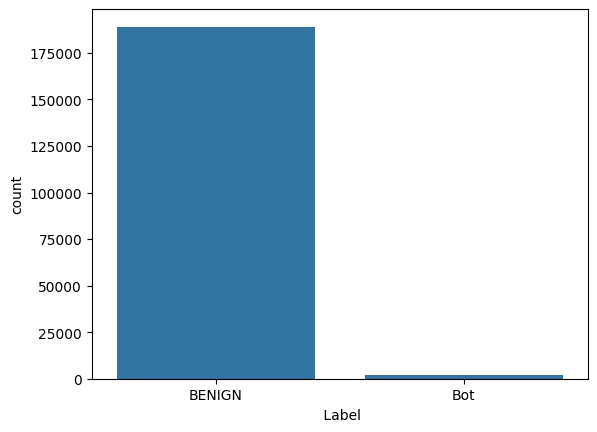

In [6]:
# Explore the distribution of the target variable (assuming ' Label' is the target)
df[' Label'].value_counts()  # Note the leading space

# Visualize the distribution of the target variable
sns.countplot(x=' Label', data=df)  # Note the leading space
plt.show()


In [7]:
# Assuming 'df' is your DataFrame and ' Label' is your target column
label_counts = df[' Label'].value_counts()
label_percentages = (label_counts / len(df)) * 100

print("Label Distribution:")
label_percentages


Label Distribution:


 Label
BENIGN    98.970858
Bot        1.029142
Name: count, dtype: float64

Encoded classes: {0: 'BENIGN', 1: 'Bot'}
Training samples before SMOTE: 133,723
Test samples: 57,310


Label
0    132347
1      1376
Name: count, dtype: int64

Training samples after SMOTE: 264,694


Label
0    132347
1    132347
Name: count, dtype: int64

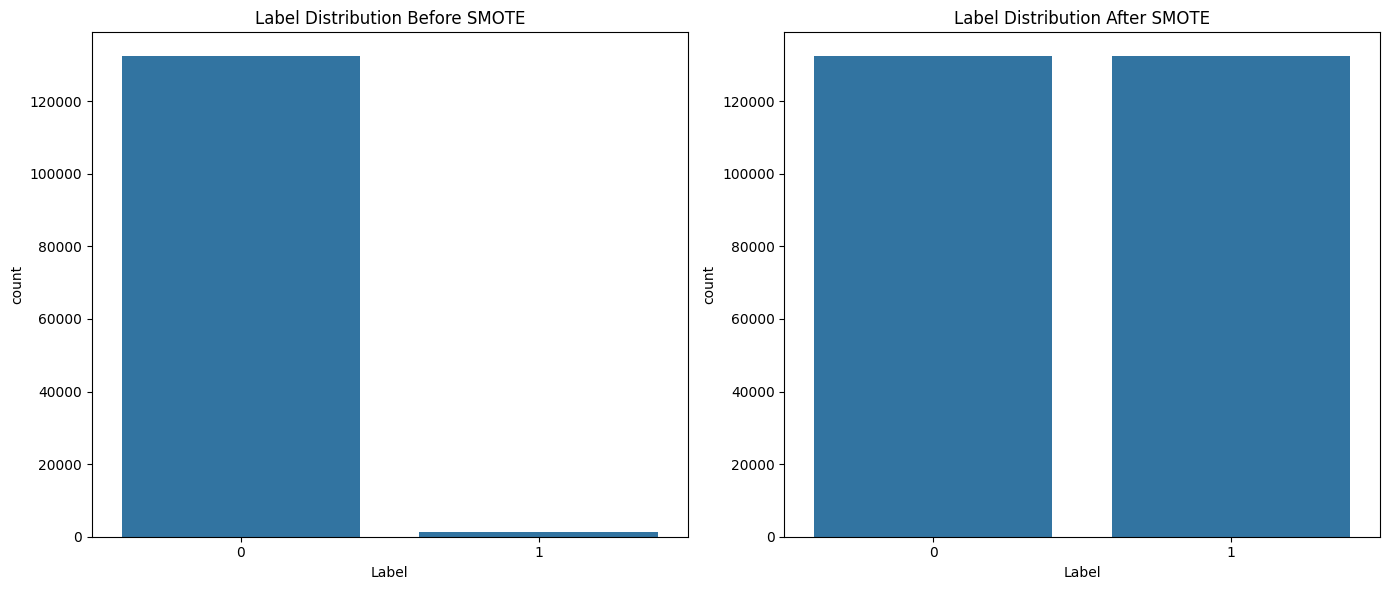

Preprocessing complete: 100%


In [8]:
# Preprocessing: encode target, clean values, split, SMOTE, and scale
from imblearn.over_sampling import SMOTE

encoder = LabelEncoder()
df["Label"] = encoder.fit_transform(df[TARGET_COL_RAW])
df.drop(columns=[TARGET_COL_RAW], inplace=True)

print("Encoded classes:", dict(enumerate(encoder.classes_)))

df.replace([np.inf, -np.inf], np.nan, inplace=True)

X = df.drop(columns=["Label"])
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print(f"Training samples before SMOTE: {len(y_train):,}")
print(f"Test samples: {len(y_test):,}")
display(pd.Series(y_train).value_counts().sort_index().rename("count"))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Training samples after SMOTE: {len(y_train_res):,}")
display(pd.Series(y_train_res).value_counts().sort_index().rename("count"))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(x=y_train, ax=ax[0])
ax[0].set_title("Label Distribution Before SMOTE")
sns.countplot(x=y_train_res, ax=ax[1])
ax[1].set_title("Label Distribution After SMOTE")
plt.tight_layout()
plt.show()

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

print("Preprocessing complete: 100%")


In [ ]:
# ML + DL training 
ml_models = {
    "Random Forest": RandomForestClassifier(random_state=42, verbose=1, n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, verbose=1),
    "SVM": SVC(kernel="rbf", probability=False, random_state=42, verbose=True),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric="logloss")
}

ml_metrics = {}
ml_predictions = {}
ml_probabilities = {}

print("\n========== ML TRAINING START ==========")
with tqdm(total=len(ml_models), desc="ML model progress", unit="model") as bar:
    for name, model in ml_models.items():
        print(f"\n[START] Training {name} ...")
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
        ml_predictions[name] = y_pred
        ml_probabilities[name] = y_prob
        ml_metrics[name] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "R2 Score": r2_score(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "MSE": mean_squared_error(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred)
        }
        print(
            f"[DONE] {name} | "
            f"Accuracy={ml_metrics[name]['Accuracy']:.4f} | "
            f"F1={ml_metrics[name]['F1 Score']:.4f}"
        )
        bar.update(1)

print("ML TRAINING COMPLETE: 100%")

dl_models = {
    "ANN": Sequential([
        Dense(32, activation="relu", input_shape=(X_train_res.shape[1],)),
        Dropout(0.5),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")
    ]),
    "Transformer": Sequential([
        Dense(64, activation="relu", input_shape=(X_train_res.shape[1],)),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ]),
    "GRU": Sequential([
        GRU(64, activation="relu", input_shape=(X_train_res.shape[1], 1)),
        Dropout(0.4),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ]),
    "Autoencoder": Sequential([
        Dense(64, activation="relu", input_shape=(X_train_res.shape[1],)),
        Dense(32, activation="relu"),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ]),
    "DNN": Sequential([
        Dense(128, activation="relu", input_shape=(X_train_res.shape[1],)),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
}

dl_metrics = {}
dl_predictions = {}
dl_probabilities = {}
dl_histories = {}

print("\n========== DEEP LEARNING TRAINING START ==========")
with tqdm(total=len(dl_models), desc="DL model progress", unit="model") as bar:
    for name, model in dl_models.items():
        print(f"\n[START] Training {name} ...")
        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
        early_stopping = EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )

        if name == "GRU":
            X_fit = X_train_res.reshape(X_train_res.shape[0], X_train_res.shape[1], 1)
            X_eval = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
        else:
            X_fit = X_train_res
            X_eval = X_test

        history = model.fit(
            X_fit, y_train_res,
            epochs=20,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stopping],
            verbose=1
        )
        dl_histories[name] = history

        y_prob = model.predict(X_eval, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
        dl_predictions[name] = y_pred
        dl_probabilities[name] = y_prob
        dl_metrics[name] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "R2 Score": r2_score(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "MSE": mean_squared_error(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred)
        }
        print(
            f"[DONE] {name} | "
            f"Accuracy={dl_metrics[name]['Accuracy']:.4f} | "
            f"F1={dl_metrics[name]['F1 Score']:.4f}"
        )
        bar.update(1)

print("DEEP LEARNING TRAINING COMPLETE: 100%")



========== ML TRAINING START ==========


ML model progress:   0%|          | 0/5 [00:00<?, ?model/s]


[START] Training Random Forest ...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   20.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


[DONE] Random Forest | Accuracy=0.9991 | F1=0.9579

[START] Training Logistic Regression ...


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


DL model progress:   0%|          | 0/5 [00:00<?, ?model/s]


[START] Training ANN ...
Epoch 1/20
  75/6618 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.7169 - loss: 0.5913 

I0000 00:00:1790706133.406570     176 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6618/6618 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9686 - loss: 0.0929 - val_accuracy: 0.9981 - val_loss: 0.0573
Epoch 2/20
6618/6618 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9797 - loss: 0.0612 - val_accuracy: 0.9983 - val_loss: 0.0400
Epoch 3/20
6618/6618 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9807 - loss: 0.0583 - val_accuracy: 0.9978 - val_loss: 0.0407
Epoch 4/20
6618/6618 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9810 - loss: 0.0575 - val_accuracy: 0.9990 - val_loss: 0.0324
Epoch 5/20
6618/6618 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9815 - loss: 0.0568 - val_accuracy: 0.9990 - val_loss: 0.0328
Epoch 6/20
6618/6618 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9816 - loss: 0.0561 - val_accuracy: 0.9989 - val_loss: 0.0322
Epoch 7/20
6618/6618 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9817 - loss: 0.0558 - val_accuracy: 0.9989 - val_loss: 0.0338
Epoch 8/20
6618/6618 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9819 - loss: 0.0549 - val

In [10]:
# Convert results to DataFrame
ml_df = pd.DataFrame(ml_metrics).T
dl_df = pd.DataFrame(dl_metrics).T
combined_df = pd.concat([ml_df, dl_df])
print(combined_df)



                     Accuracy   R2 Score       MAE       MSE  F1 Score
Random Forest        0.999128   0.914373  0.000872  0.000872  0.957912
Logistic Regression  0.956133  -3.305340  0.043867  0.043867  0.317590
SVM                  0.966027  -2.334327  0.033973  0.033973  0.376960
Naive Bayes          0.794556 -19.163513  0.205444  0.205444  0.091092
XGBoost              0.999319   0.933211  0.000681  0.000681  0.967795
ANN                  0.976060  -1.349613  0.023940  0.023940  0.460268
Transformer          0.975659  -1.389001  0.024341  0.024341  0.456564
GRU                  0.975484  -1.406127  0.024516  0.024516  0.456059
Autoencoder          0.973530  -1.597932  0.026470  0.026470  0.435850
DNN                  0.976967  -1.260560  0.023033  0.023033  0.469027


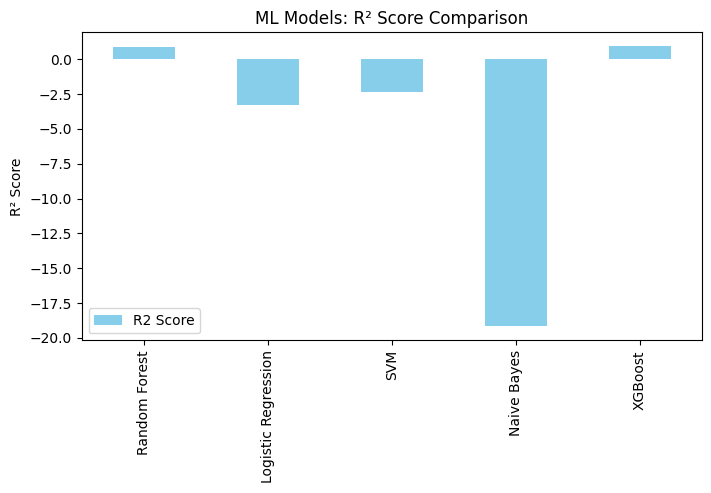

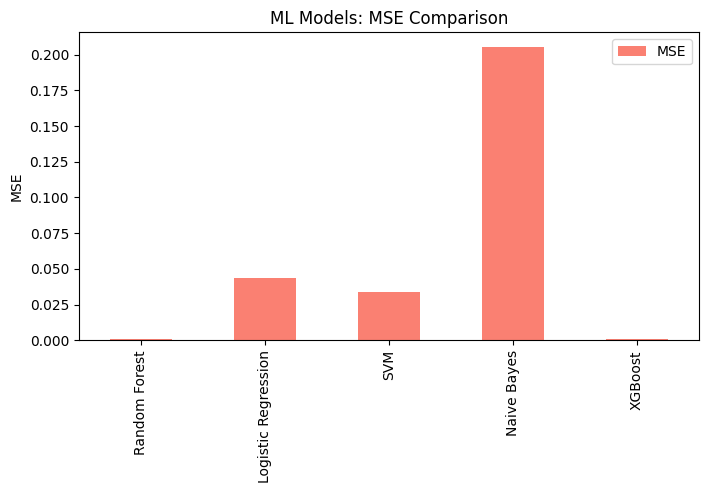

In [11]:
import matplotlib.pyplot as plt

# Plot ML R2 comparison
ml_df[['R2 Score']].plot(kind='bar', figsize=(8, 4), title="ML Models: R² Score Comparison", color='skyblue')
plt.ylabel("R² Score")
plt.show()

# Plot ML MSE comparison
ml_df[['MSE']].plot(kind='bar', figsize=(8, 4), title="ML Models: MSE Comparison", color='salmon')
plt.ylabel("MSE")
plt.show()




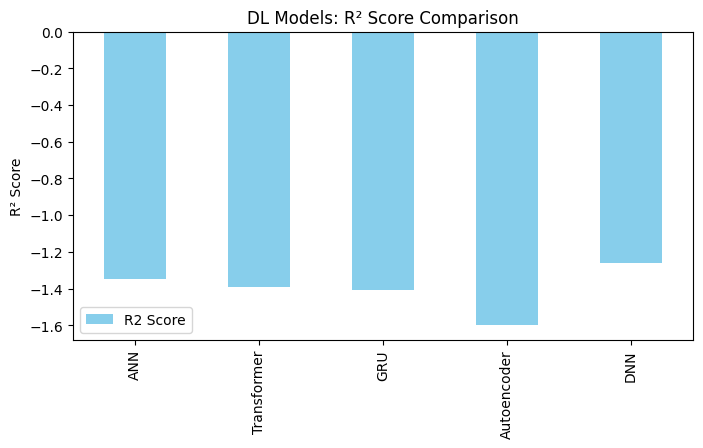

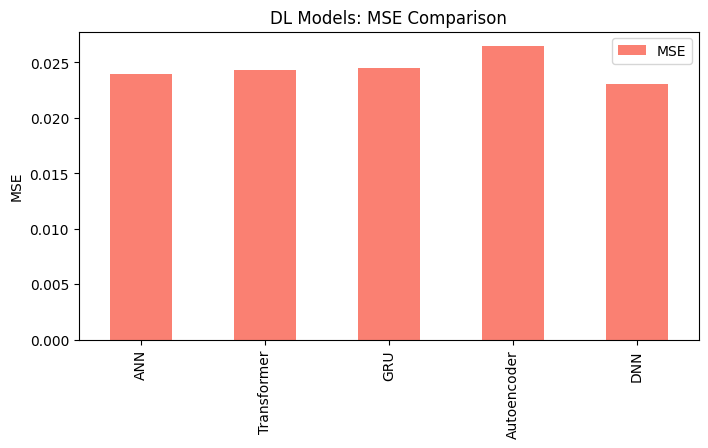

In [12]:
# Plot DL R2 comparison
dl_df[['R2 Score']].plot(kind='bar', figsize=(8, 4), title="DL Models: R² Score Comparison", color='skyblue')
plt.ylabel("R² Score")
plt.show()

# Plot DL MSE comparison
dl_df[['MSE']].plot(kind='bar', figsize=(8, 4), title="DL Models: MSE Comparison", color='salmon')
plt.ylabel("MSE")
plt.show()



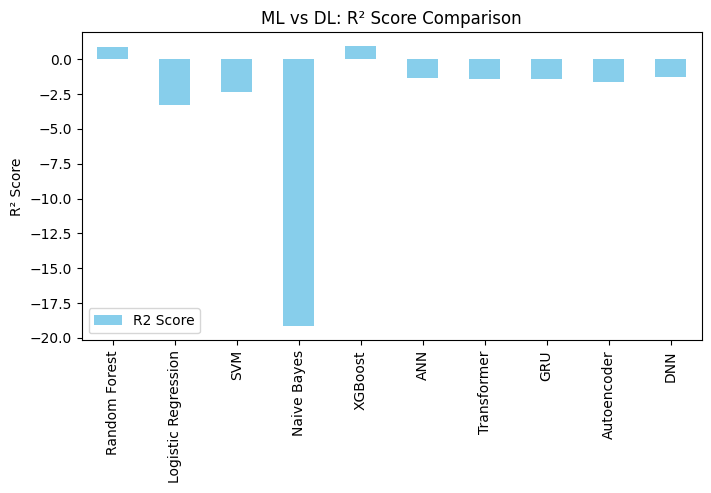

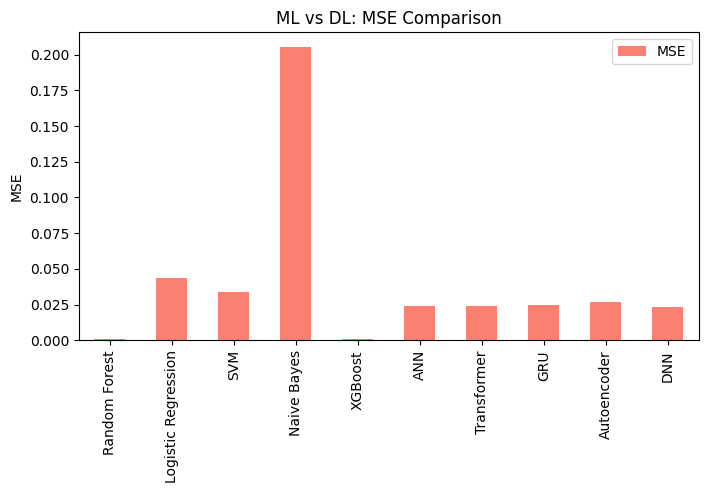

In [13]:
# Plot Combined R2 comparison
combined_df[['R2 Score']].plot(kind='bar', figsize=(8, 4), title="ML vs DL: R² Score Comparison", color='skyblue')
plt.ylabel("R² Score")
plt.show()

# Plot Combined MSE comparison
combined_df[['MSE']].plot(kind='bar', figsize=(8, 4), title="ML vs DL: MSE Comparison", color='salmon')
plt.ylabel("MSE")
plt.show()

## Advanced evaluation: classification-focused metrics


In [14]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    balanced_accuracy_score, matthews_corrcoef, roc_curve, precision_recall_curve,
    auc, ConfusionMatrixDisplay
)

advanced_rows = []
all_predictions = {**ml_predictions, **dl_predictions}
all_probabilities = {**ml_probabilities, **dl_probabilities}

for name, y_pred in all_predictions.items():
    y_prob = all_probabilities[name]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    advanced_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'Specificity': specificity,
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob),
        'MCC': matthews_corrcoef(y_test, y_pred)
    })

advanced_metrics_df = pd.DataFrame(advanced_rows).set_index('Model').sort_values('F1', ascending=False)
display(advanced_metrics_df.round(4))


,Accuracy,Precision,Recall,F1,Specificity,Balanced Accuracy,ROC-AUC,PR-AUC,MCC
Model,,,,,,,,,
XGBoost,0.9993,0.9436,0.9932,0.9678,0.9994,0.9963,1.0000,0.9987,0.9678
Random Forest,0.9991,0.9515,0.9644,0.9579,0.9995,0.9819,0.9999,0.9888,0.9575
DNN,0.9770,0.3075,0.9881,0.4690,0.9769,0.9825,0.9972,0.8602,0.5446
ANN,0.9761,0.2997,0.9915,0.4603,0.9759,0.9837,0.9967,0.8374,0.5384
Transformer,0.9757,0.2964,0.9932,0.4566,0.9755,0.9843,0.9968,0.8397,0.5358
GRU,0.9755,0.2955,0.9983,0.4561,0.9752,0.9868,0.9980,0.8754,0.5364
Autoencoder,0.9735,0.2792,0.9932,0.4358,0.9733,0.9833,0.9967,0.8357,0.5194
SVM,0.9660,0.2323,0.9983,0.3770,0.9657,0.9820,0.9863,0.2704,0.4732
Logistic Regression,0.9561,0.1891,0.9915,0.3176,0.9558,0.9736,0.9913,0.4775,0.4231


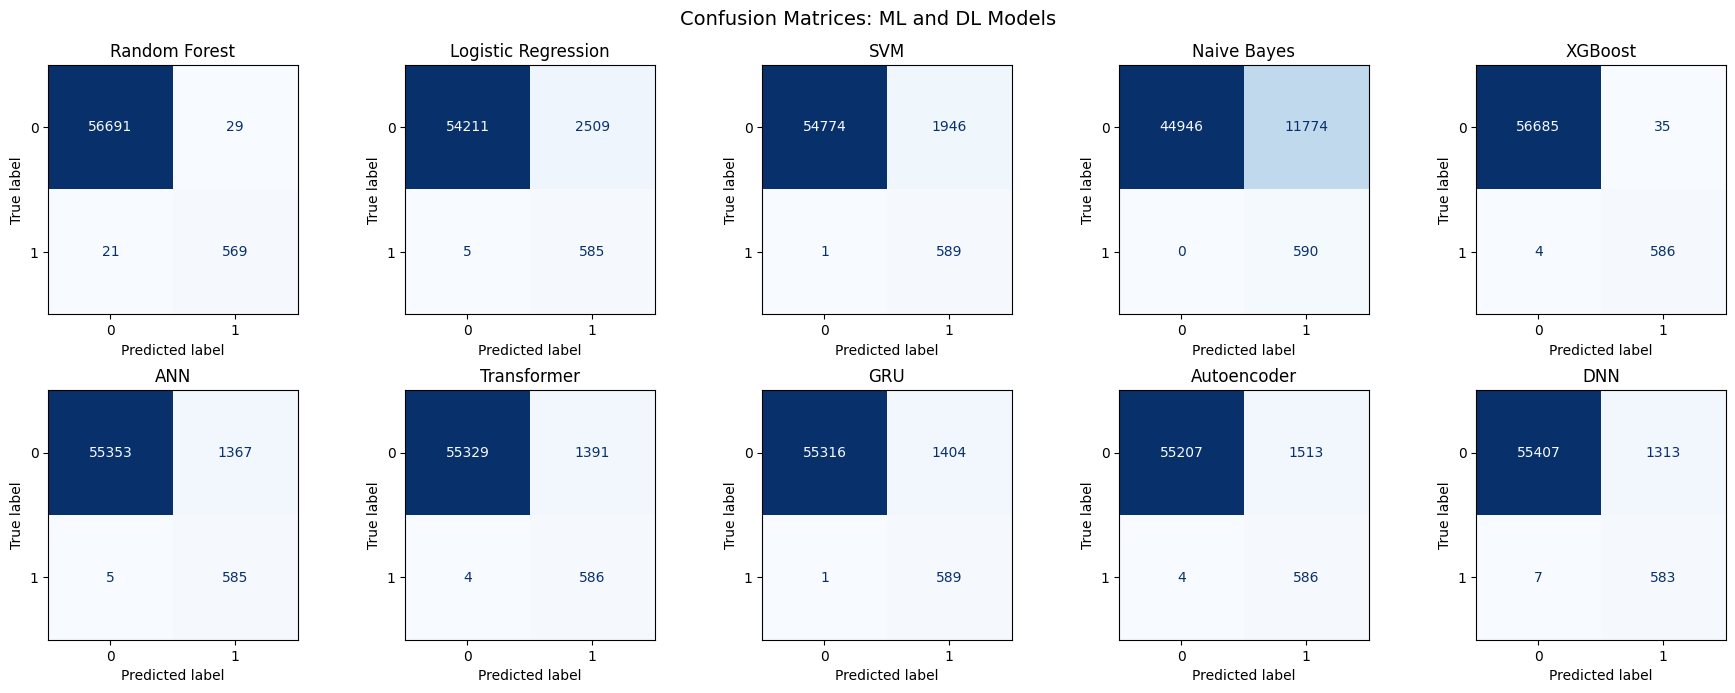

In [ ]:
# Confusion matrices for all models
n_models = len(all_predictions)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

for ax, (name, y_pred) in zip(axes, all_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(name)

for ax in axes[n_models:]:
    ax.axis('off')

plt.suptitle('Confusion Matrices: ML and DL Models', fontsize=14)
plt.tight_layout()
plt.show()


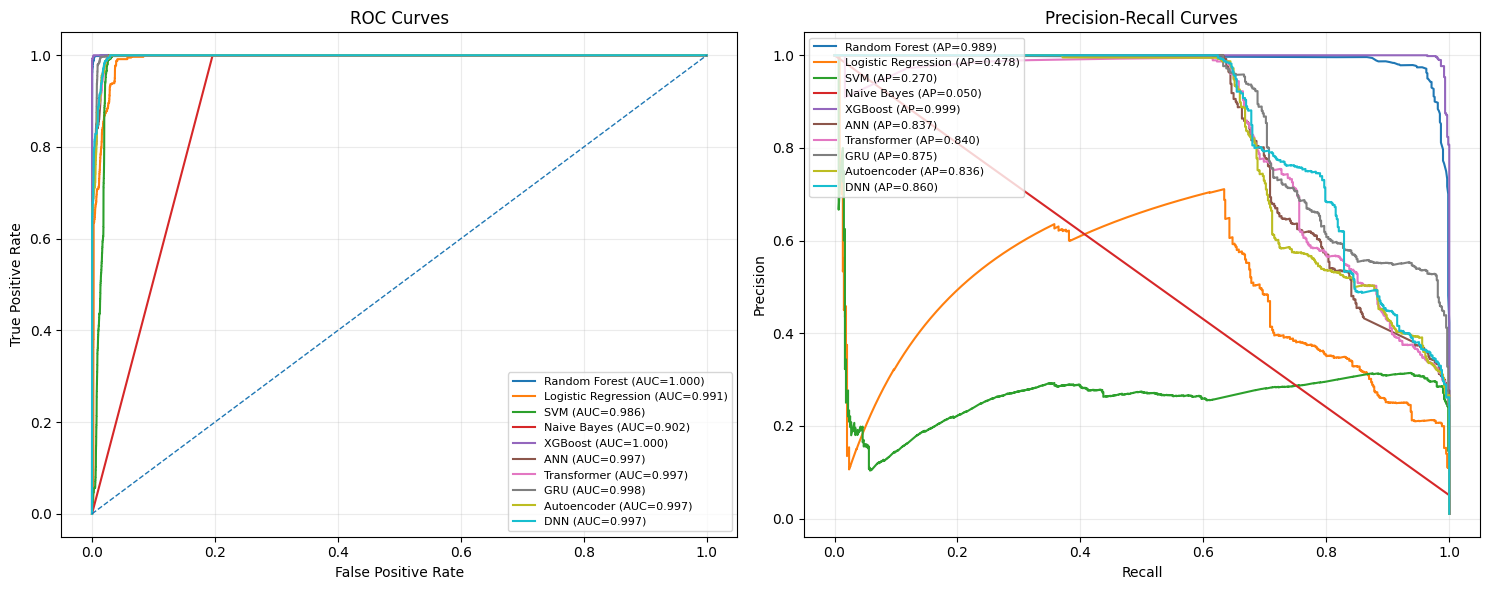

In [ ]:
# ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, y_prob in all_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_prob):.3f})")

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(recall, precision, label=f"{name} (AP={average_precision_score(y_test, y_prob):.3f})")

axes[0].plot([0, 1], [0, 1], '--', linewidth=1)
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


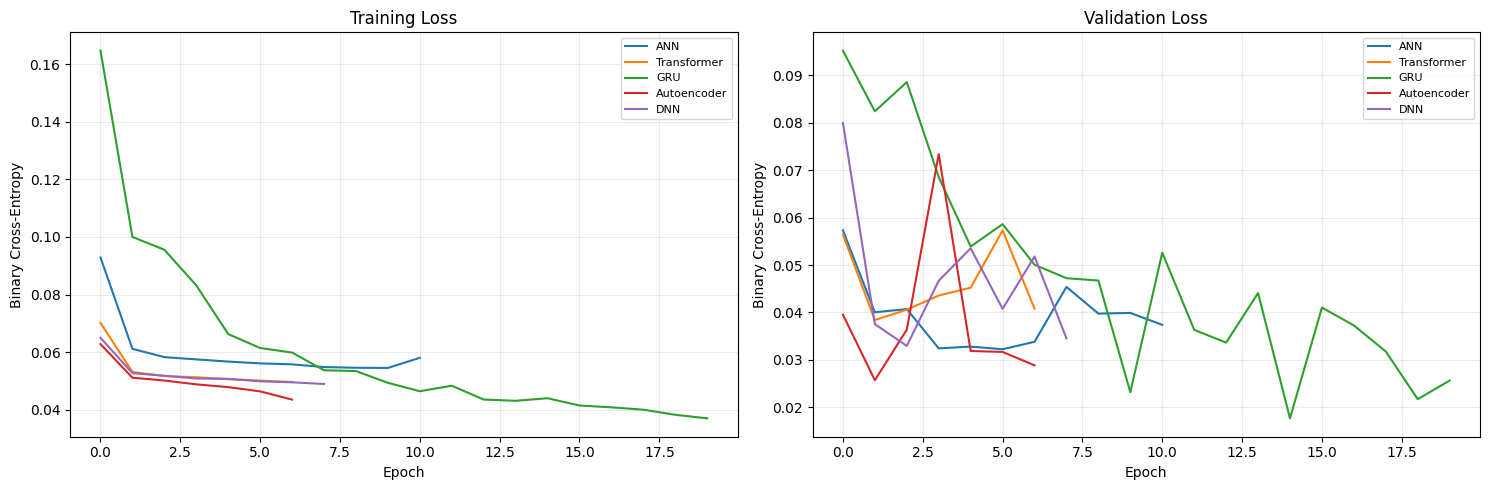

In [ ]:
# DL learning curves: useful for detecting underfitting/overfitting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, history in dl_histories.items():
    axes[0].plot(history.history['loss'], label=name)
    axes[1].plot(history.history['val_loss'], label=name)

axes[0].set_title('Training Loss')
axes[1].set_title('Validation Loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Binary Cross-Entropy')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Explainable AI (XAI) with SHAP
This section adds **SHAP (SHapley Additive exPlanations)** without changing the dataset or model families. It provides:
- global feature importance for the tree models,
- feature impact direction/magnitude through SHAP summary plots,
- a local explanation for an individual network-flow prediction, and
- permutation importance as a model-agnostic XAI check across all ML models.




In [ ]:
# Install/import SHAP if necessary (Colab-friendly)
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
    import shap

# Keep XAI computationally manageable while preserving representative test examples
X_test_df = pd.DataFrame(X_test, columns=X.columns)
X_background = X_test_df.sample(min(200, len(X_test_df)), random_state=42)
X_explain = X_test_df.sample(min(500, len(X_test_df)), random_state=42)

print('XAI background samples:', len(X_background))
print('XAI explanation samples:', len(X_explain))


XAI background samples: 200
XAI explanation samples: 500


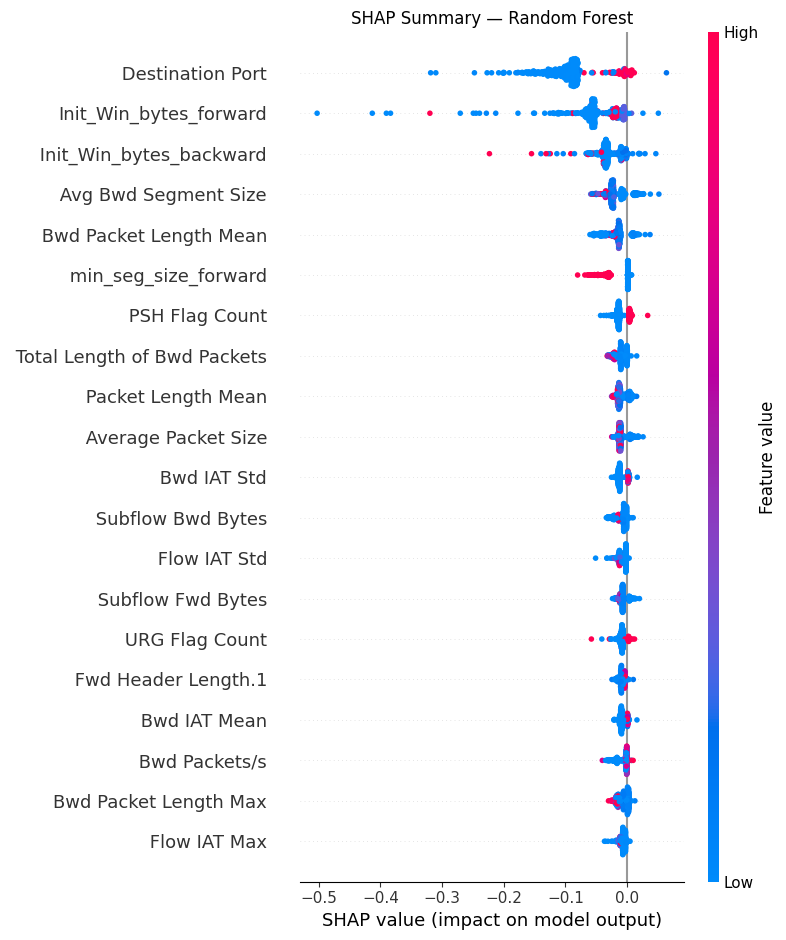

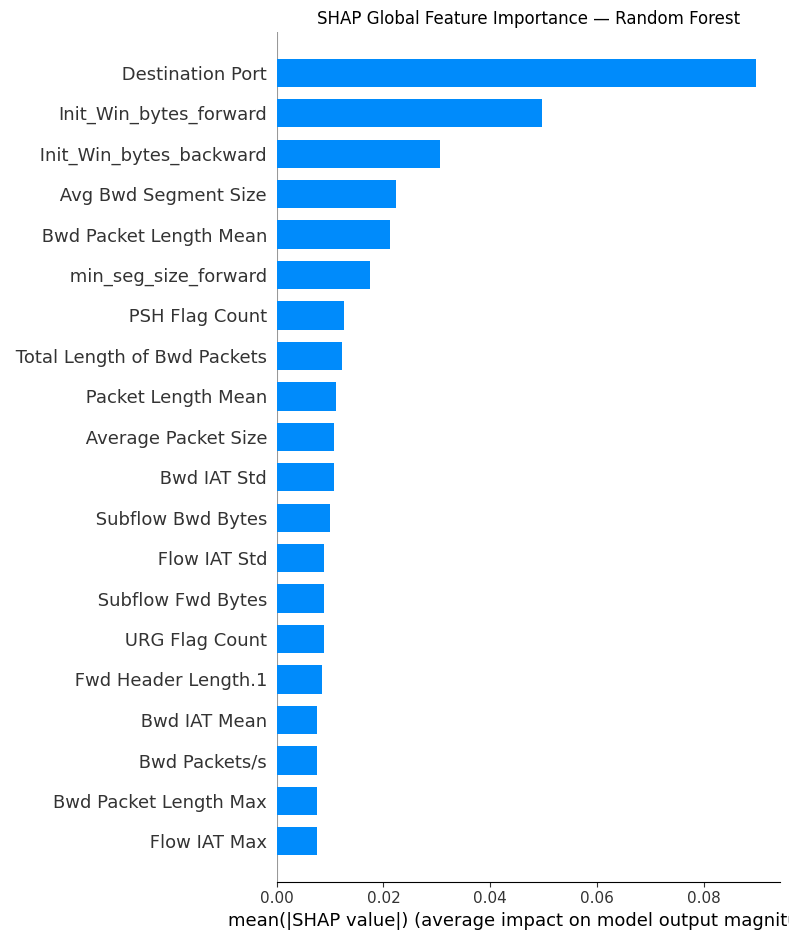

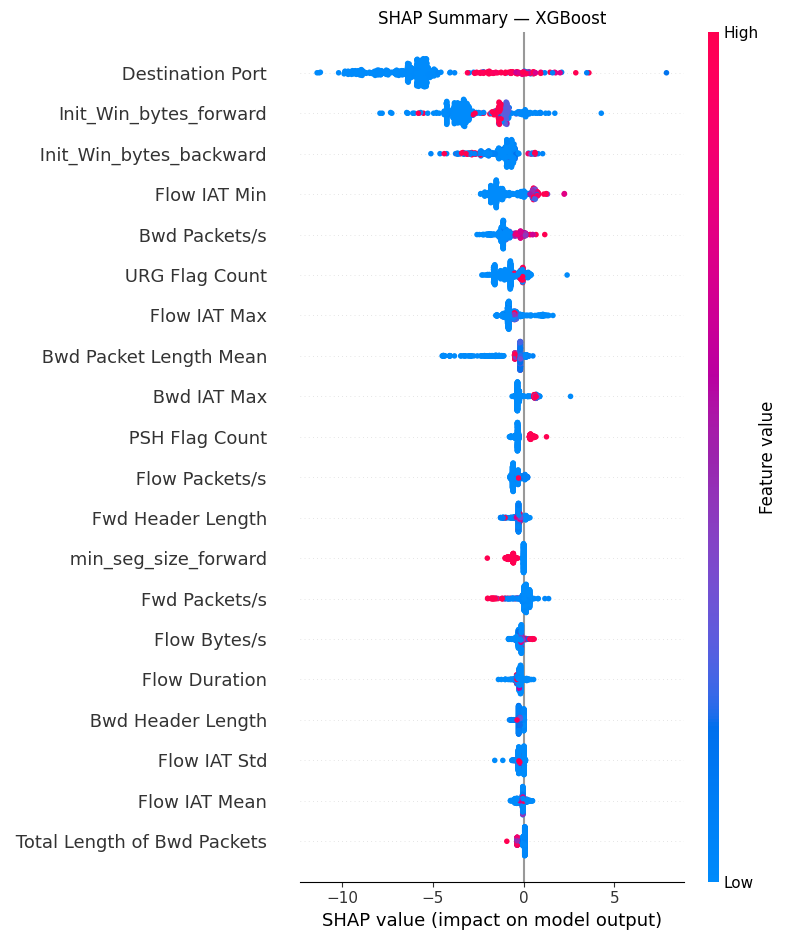

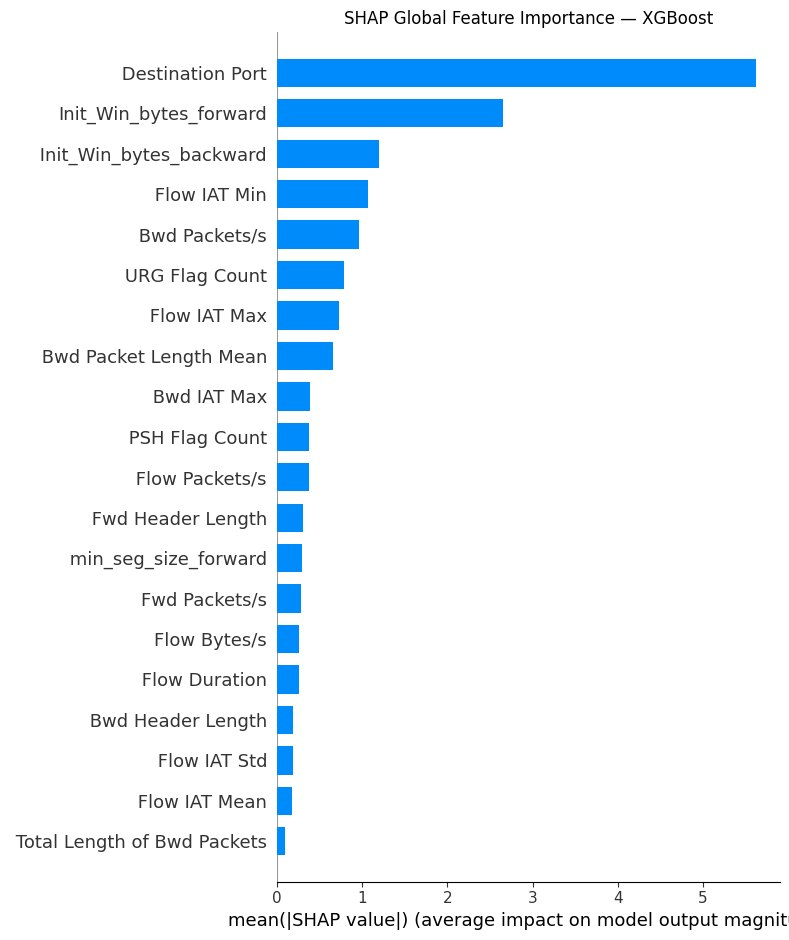

In [ ]:
# SHAP global explanations for the tree-based models
# TreeExplainer is exact/fast for Random Forest and XGBoost compared with model-agnostic explainers.
shap_values_by_model = {}

for model_name in ['Random Forest', 'XGBoost']:
    model = ml_models[model_name]
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_explain)

    # Binary classification SHAP can be returned as either an array or a list depending on SHAP version.
    if isinstance(sv, list):
        sv_plot = sv[1] if len(sv) > 1 else sv[0]
    else:
        sv_plot = sv
        if getattr(sv_plot, 'ndim', 0) == 3:
            sv_plot = sv_plot[:, :, 1]

    shap_values_by_model[model_name] = sv_plot

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_plot, X_explain, feature_names=X.columns, max_display=20, show=False)
    plt.title(f'SHAP Summary — {model_name}')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 7))
    shap.summary_plot(sv_plot, X_explain, feature_names=X.columns, plot_type='bar', max_display=20, show=False)
    plt.title(f'SHAP Global Feature Importance — {model_name}')
    plt.tight_layout()
    plt.show()


,Random Forest,XGBoost,Mean |SHAP|
Destination Port,0.089844,5.621305,2.855574
Init_Win_bytes_forward,0.049785,2.653060,1.351422
Init_Win_bytes_backward,0.030583,1.201349,0.615966
Flow IAT Min,0.003887,1.068374,0.536130
Bwd Packets/s,0.007624,0.959809,0.483717
URG Flag Count,0.008900,0.787023,0.397961
Flow IAT Max,0.007461,0.726362,0.366911
Bwd Packet Length Mean,0.021171,0.655702,0.338437
Bwd IAT Max,0.006585,0.391071,0.198828
PSH Flag Count,0.012641,0.380365,0.196503


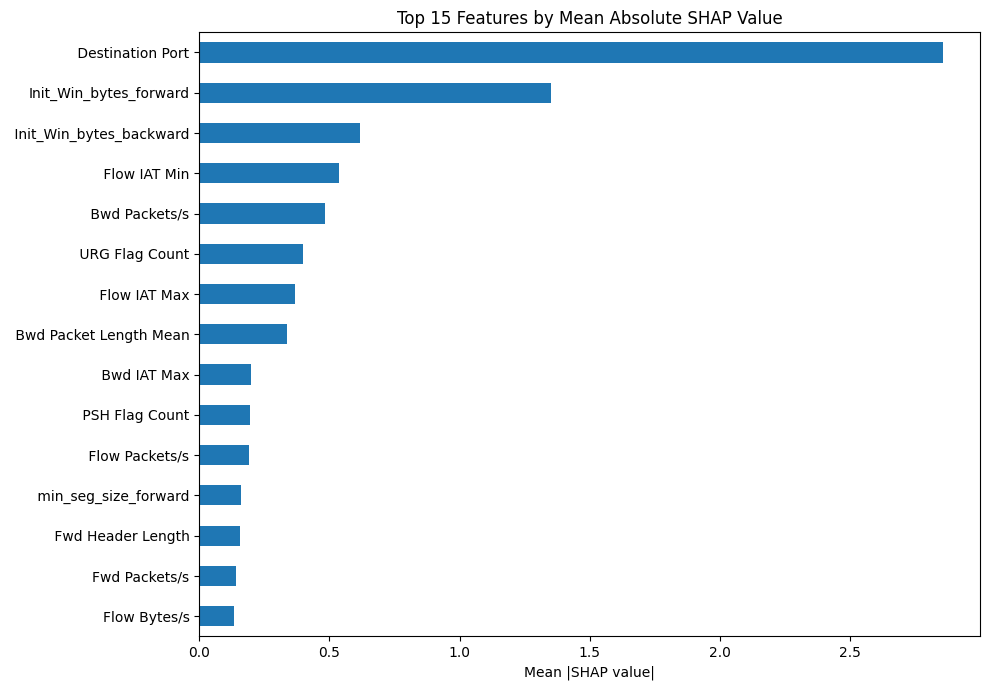

In [ ]:
# Compare SHAP feature importance between Random Forest and XGBoost
shap_importance = pd.DataFrame({
    name: np.abs(values).mean(axis=0)
    for name, values in shap_values_by_model.items()
}, index=X.columns)

shap_importance['Mean |SHAP|'] = shap_importance.mean(axis=1)
shap_importance = shap_importance.sort_values('Mean |SHAP|', ascending=False)

display(shap_importance.head(20).round(6))

plt.figure(figsize=(10, 7))
shap_importance['Mean |SHAP|'].head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Features by Mean Absolute SHAP Value')
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()


Model: XGBoost
Predicted class: BENIGN
Attack probability: 0.0000


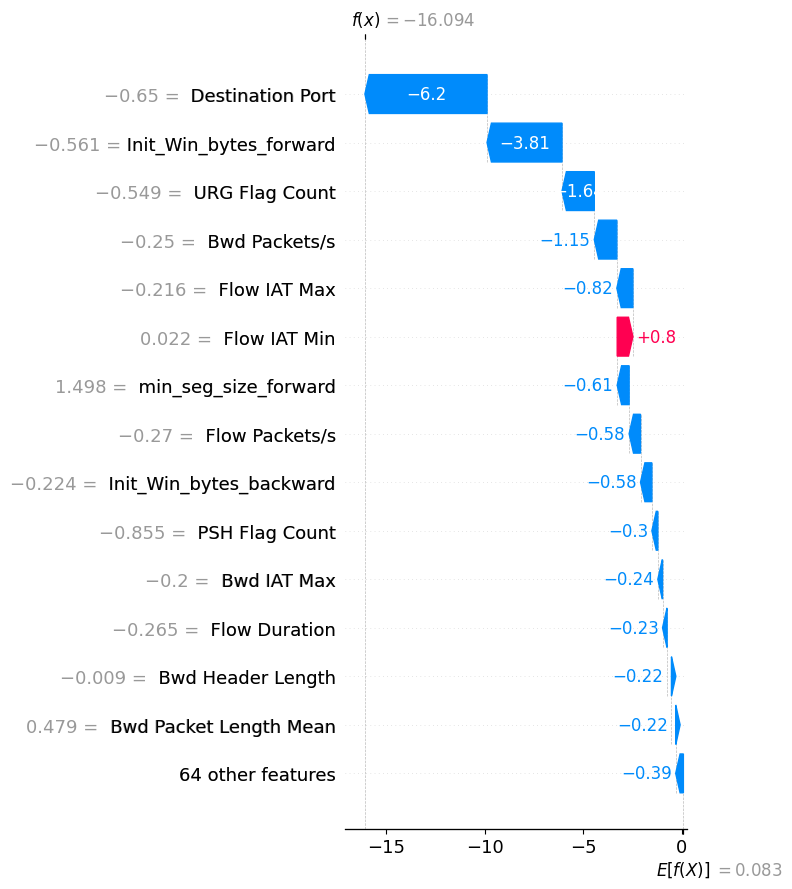

In [ ]:
# Local SHAP explanation for one network-flow observation
# This shows which features pushed the selected tree model toward benign/attack.
local_model_name = 'XGBoost'
local_model = ml_models[local_model_name]
local_explainer = shap.TreeExplainer(local_model)

local_row = X_test_df.iloc[[0]]
local_sv = local_explainer.shap_values(local_row)
if isinstance(local_sv, list):
    local_sv = local_sv[1] if len(local_sv) > 1 else local_sv[0]
if getattr(local_sv, 'ndim', 0) == 3:
    local_sv = local_sv[:, :, 1]

pred_label = int(local_model.predict(local_row)[0])
pred_prob = float(local_model.predict_proba(local_row)[0, 1])
print(f'Model: {local_model_name}')
print(f'Predicted class: {encoder.inverse_transform([pred_label])[0]}')
print(f'Attack probability: {pred_prob:.4f}')

# Waterfall plot gives a case-level explanation.
base_value = local_explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.asarray(base_value).reshape(-1)[-1]

local_exp = shap.Explanation(
    values=local_sv[0],
    base_values=float(base_value),
    data=local_row.iloc[0].values,
    feature_names=X.columns.tolist()
)
shap.plots.waterfall(local_exp, max_display=15, show=False)
plt.tight_layout()
plt.show()
